In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from tqdm import tqdm

In [78]:
# Component-based normalization
ame = 'hcircpgd'
path1 = f'/home/kale-chen/Documents/PET/TPPT2026/data/hcircpgd.bin'
path2 = '/home/kale-chen/Documents/Geant4/TPPTsim/temp/idsmapped.bin'
num_cols1, num_cols2, data_size = 4,  2, 2
num_rows1 = os.path.getsize(path1) // (num_cols1 * data_size)
data1 = np.memmap(path1, dtype = np.int16, mode = 'r', shape = (num_rows1, num_cols1))
eventcounts1 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows1, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if num_cols1 == 3 or num_cols1 == 2 or num_cols1 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols1 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts1, (idls, idrs), 1)
num_rows2 = os.path.getsize(path2) // (num_cols2 * data_size)
data2 = np.memmap(path2, dtype = np.int16, mode = 'r', shape = (num_rows2, num_cols2))
eventcounts2 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows2, 1000000), desc='Event counts'):
    chunk = data2[i:i+1000000]
    if num_cols2 == 3 or num_cols2 == 2 or num_cols2 == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols2 == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(eventcounts2, (idls, idrs), 1)

Event counts: 100%|██████████| 5/5 [00:00<00:00, 10.06it/s]


In [15]:
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]
print(map[0:5])
def lor_to_sinogram_coords(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1

    # Normal vector to the LOR
    nx = -dy
    ny = dx

    norm = np.hypot(nx, ny)
    nx /= norm
    ny /= norm

    theta = np.arctan2(ny, nx)

    # Signed distance from origin
    s = x1 * nx + y1 * ny

    # Put theta in [0, pi)
    if theta < 0:
        theta += np.pi
        s = -s
    elif theta >= np.pi:
        theta -= np.pi
        s = -s

    return theta, s

def ramp_filter_sinogram(sinogram, ds):
    n_theta, n_s = sinogram.shape

    freqs = np.fft.fftfreq(n_s, d=ds)

    # ramp filter
    ramp = np.abs(freqs)

    filtered = np.zeros_like(sinogram)

    for i in range(n_theta):
        P = np.fft.fft(sinogram[i])
        filtered[i] = np.real(np.fft.ifft(P * ramp))

    return filtered

def backproject(filtered_sino, theta_centers, s_centers, X, Y):
    image = np.zeros_like(X, dtype=np.float64)

    for i, theta in enumerate(theta_centers):
        s = X * np.cos(theta) + Y * np.sin(theta)

        projection = np.interp(
            s.ravel(),
            s_centers,
            filtered_sino[i],
            left=0,
            right=0
        ).reshape(X.shape)

        image += projection

    image *= np.pi / len(theta_centers)

    return image

[[ 117.3250734 -120.1245968   38.       ]
 [ 114.8917743 -122.2028306   38.       ]
 [ 112.4584752 -124.2810643   28.4      ]
 [ 117.3250734 -120.1245968   34.8      ]
 [ 110.0251761 -126.3592981   34.8      ]]


In [76]:
n_theta, n_s = 200, 200
theta_min, theta_max = 30, 150
s_max = 150
def make_sinogram(eventcounts, map = map, n_theta=n_theta, n_s=n_s, theta_min=theta_min, theta_max=theta_max, s_max=s_max):
    theta_edges = np.linspace(theta_min * np.pi / 180, theta_max * np.pi / 180, n_theta + 1)
    s_edges = np.linspace(-s_max, s_max, n_s + 1)
    sinogram = np.zeros((n_theta, n_s), dtype=np.float32)
    for i in tqdm(range(3072)):
        for j in range(3072):
            x1, y1 = map[i + 3072, 0], map[i + 3072, 1]
            x2, y2 = map[j, 0], map[j, 1]
            t, s = lor_to_sinogram_coords(x1, y1, x2, y2)
            itheta = np.searchsorted(theta_edges, t, side='right') - 1
            is_ = np.searchsorted(s_edges, s, side='right') - 1
            if (0 <= itheta < n_theta) and (0 <= is_ < n_s):
                sinogram[itheta, is_] += eventcounts[i, j]

    return sinogram, theta_edges, s_edges

In [41]:
N = 200
pixel_size = 2  # mm

coords = (np.arange(N) - (N - 1) / 2) * pixel_size
X, Y = np.meshgrid(coords, coords, indexing='xy')

theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])
ds = s_centers[1] - s_centers[0]

recon = backproject(
    filtered,
    theta_centers,
    s_centers,
    X,
    Y
)
reconraw = backproject(
    sinogram,
    theta_centers,
    s_centers,
    X,
    Y
)

In [105]:
def sinogram_heatmap_nice(data, fig_num, cmap='hot', name = 'Sinogram'):
    fig = plt.figure(fig_num, figsize=(5, 4.5))
    gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
    axhm = fig.add_subplot(gs[0, 0])
    axcbar = fig.add_subplot(gs[0, 1])
    hm = axhm.imshow(data, cmap=cmap, aspect='auto', extent=[-s_max, s_max, 0, 180])
    axhm.set_xticks(np.linspace(-s_max, s_max, 5))
    axhm.set_yticks(np.linspace(0, 180, 5))
    axhm.set_xlabel('Radius (mm)')
    axhm.set_ylabel('Angle (deg)')
    axhm.set_title(name)
    cbar = fig.colorbar(hm, cax=axcbar)
    cbar.set_ticks(np.linspace(np.nanmin(data), np.nanmax(data), 5))
    cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(data), np.nanmax(data), 5)]) 
    axhm.grid(True, color = 'white', linewidth = 0.5)
    return hm

def recon_heatmap_nice(data, fig_num, cmap='hot', name = 'FBP Recon'):
    fig = plt.figure(fig_num, figsize=(5, 4.5))
    gs = GridSpec(1, 2, width_ratios=[9, 1], hspace=0, wspace=0)
    axhm = fig.add_subplot(gs[0, 0])
    axcbar = fig.add_subplot(gs[0, 1])
    hm = axhm.imshow(data, cmap=cmap, aspect='auto', extent=[-N/2 * pixel_size, N/2 * pixel_size, -N/2 * pixel_size, N/2 * pixel_size])
    axhm.set_xticks(np.linspace(-N/2 * pixel_size, N/2 * pixel_size, 5))
    axhm.set_yticks(np.linspace(-N/2 * pixel_size, N/2 * pixel_size, 5))
    axhm.set_xlabel('x (mm)')
    axhm.set_ylabel('y (mm)')
    axhm.set_title(name)
    cbar = fig.colorbar(hm, cax=axcbar)
    cbar.set_ticks(np.linspace(np.nanmin(data), np.nanmax(data), 5))
    cbar.set_ticklabels([f"{tick:.2e}" for tick in np.linspace(np.nanmin(data), np.nanmax(data), 5)]) 
    return hm


In [79]:
sinogram1, theta_edges1, s_edges1 = make_sinogram(eventcounts1)
sinogram2, theta_edges2, s_edges2 = make_sinogram(eventcounts2)

100%|██████████| 3072/3072 [00:34<00:00, 88.69it/s]


/tmp/ipykernel_4155447/3764833175.py:4: RuntimeWarning: divide by zero encountered in divide
  ratio = sinogram1copy / sinogram2copy
/tmp/ipykernel_4155447/3764833175.py:4: RuntimeWarning: invalid value encountered in divide
  ratio = sinogram1copy / sinogram2copy


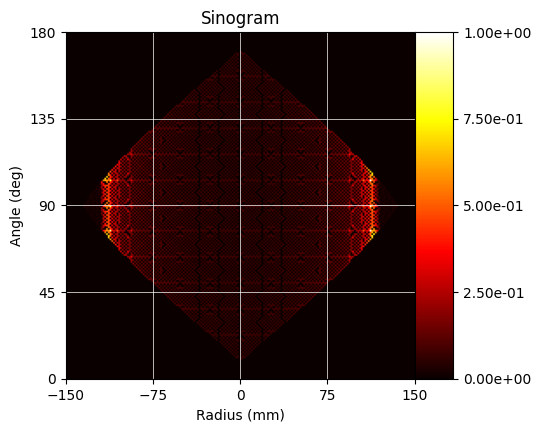

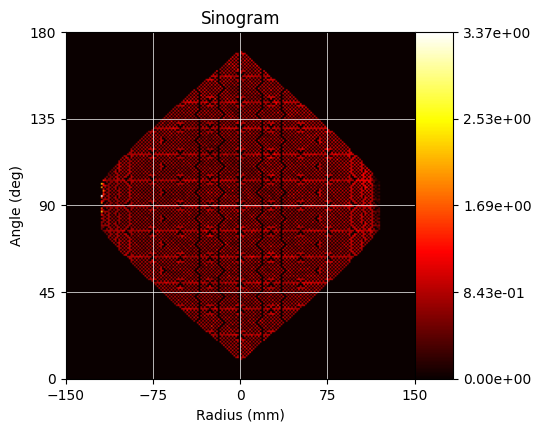

In [108]:
sinogram1copy = sinogram1.copy() / np.max(sinogram1)
sinogram_heatmap_nice(sinogram1copy, 0)
sinogram2copy = sinogram2.copy() / np.max(sinogram2)
ratio = sinogram1copy / sinogram2copy
ratio[(ratio > 2) | (np.isnan(ratio))] = 0
sinogram_heatmap_nice(np.power(ratio, 2), 2)
plt.show()

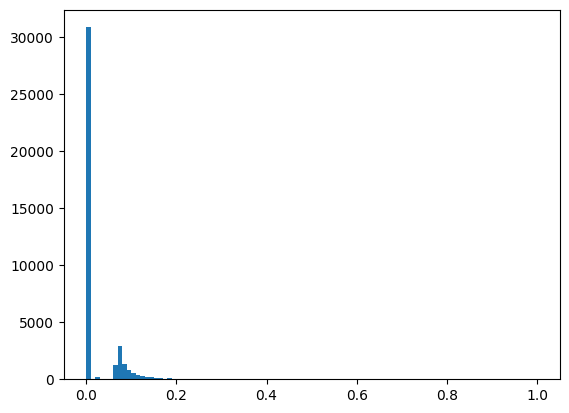

In [98]:
plt.hist(sinogram1copy.flatten(), bins=100)
plt.show()